Found 4541 images.


Extracting ORB features:   0%|                                                                | 0/4541 [00:00<?, ?it/s]

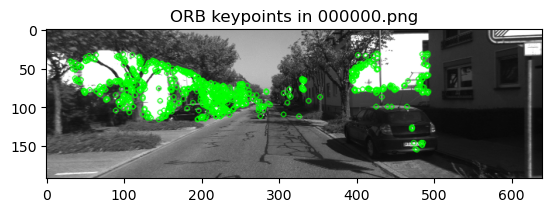

Extracting ORB features:   0%|                                                        | 1/4541 [00:00<32:54,  2.30it/s]

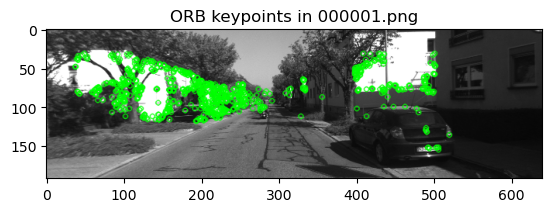

Extracting ORB features:   0%|                                                        | 2/4541 [00:00<31:59,  2.36it/s]

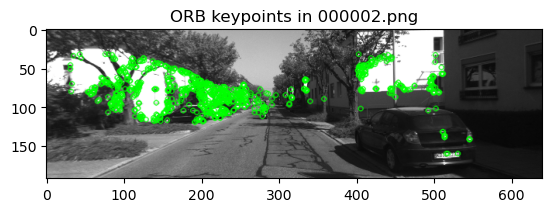

Extracting ORB features: 100%|█████████████████████████████████████████████████████| 4541/4541 [04:02<00:00, 18.75it/s]


Saved descriptors → orb_descriptors_seq00.npy


In [2]:
import cv2
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# -----------------------------
# 1. Set paths
# -----------------------------
SEQ_PATH = "data_odometry_gray/dataset/sequences/00/image_0"   
SAVE_DESCRIPTORS = True                                # store features for later matching

# -----------------------------
# 2. ORB feature extractor
# -----------------------------
orb = cv2.ORB_create(
    nfeatures=1000,     # number of keypoints per image
    scaleFactor=1.2,
    nlevels=8,
    edgeThreshold=31,
    firstLevel=0,
    WTA_K=2,
    scoreType=cv2.ORB_HARRIS_SCORE,
    patchSize=31,
    fastThreshold=20
)

# -----------------------------
# 3. Read all image files
# -----------------------------
image_files = sorted([os.path.join(SEQ_PATH, f) for f in os.listdir(SEQ_PATH) if f.endswith('.png')])
print(f"Found {len(image_files)} images.")

# -----------------------------
# 4. Loop through images & extract features
# -----------------------------
features = []  # list of (keypoints, descriptors)

for img_path in tqdm(image_files, desc="Extracting ORB features"):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    # Optional preprocessing
    img = cv2.resize(img, (640, 192))  # resize for consistency
    
    keypoints, descriptors = orb.detectAndCompute(img, None)
    features.append((keypoints, descriptors))
    
    # Visualization for first few images
    if len(features) <= 3:
        img_kp = cv2.drawKeypoints(img, keypoints, None, color=(0,255,0), flags=0)
        plt.imshow(img_kp, cmap='gray')
        plt.title(f"ORB keypoints in {os.path.basename(img_path)}")
        plt.show()

# -----------------------------
# 5. Save descriptors for later (optional)
# -----------------------------
if SAVE_DESCRIPTORS:
    descriptors_list = [f[1] for f in features]  # list of descriptor arrays
    np.save("orb_descriptors_seq00.npy", np.array(descriptors_list, dtype=object))
    print("Saved descriptors → orb_descriptors_seq00.npy")
